<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Time Series EDA Lab

---

This lab covers the exploratory toolkit you need **before** fitting any time series model. It walks through: 

- Loading and indexing a real-world time series
- Visualizing trend by resampling / rolling smoothing
- Testing for stationarity with the Augmented Dickey-Fuller (ADF) test
- Diagnosing the series using ACF and PACF plots

## About the Data

`residents.csv` contains a **quarterly resident population count**, in thousands, from **April 1971 to April 1993** (89 quarters):

| Column | Description |
|---|---|
| `date` | Quarter (month-year, e.g. `04-1971`) |
| `residents` | Resident population that quarter, in thousands |

We're going to hold the **final 8 quarters (1991–1993)** out completely. Everything in this EDA lab uses only the first **81 quarters (1971–1990)**.

In [28]:
# %pip install matplotlib

In [29]:
# %pip install seaborn

In [30]:
# %pip install statsmodels

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

## Part 1 - Load and Set Aside the Holdout 

### 1. Load `residents.csv`, parse `date` as a datetime (format is `MM-YYYY`), and set it as the index.

In [32]:
# Load the data and parse the date column (format is MM-YYYY)
df = pd.read_csv('./data/residents.csv')
df['date'] = pd.to_datetime(df['date'], format='%m-%Y')
df.set_index('date', inplace=True)

df.head()

,residents
date,
1971-04-01,13067.3
1971-07-01,13130.5
1971-10-01,13198.4
1972-01-01,13254.2
1972-04-01,13303.7


### 2. Set aside the final 8 quarters (1991–1993) as `holdout_df`. Keep the remaining 81 quarters (1971–1990) as `df_eda`.

In [33]:
# 81 rows for EDA (1971-1990), last 8 rows held out (1991-1993)
df_eda = df.iloc[:81].copy()
holdout_df = df.iloc[81:].copy()

print('df_eda shape:', df_eda.shape)
print('holdout_df shape:', holdout_df.shape)
df_eda.tail()

df_eda shape: (81, 1)
holdout_df shape: (8, 1)


,residents
date,
1990-04-01,17085.4
1990-07-01,17106.9
1990-10-01,17169.4
1991-01-01,17239.4
1991-04-01,17292.0


### 3. Plot the raw `residents` series. What do you notice about the overall trend? Does the quarter-to-quarter spread look roughly constant, or does it change over time?

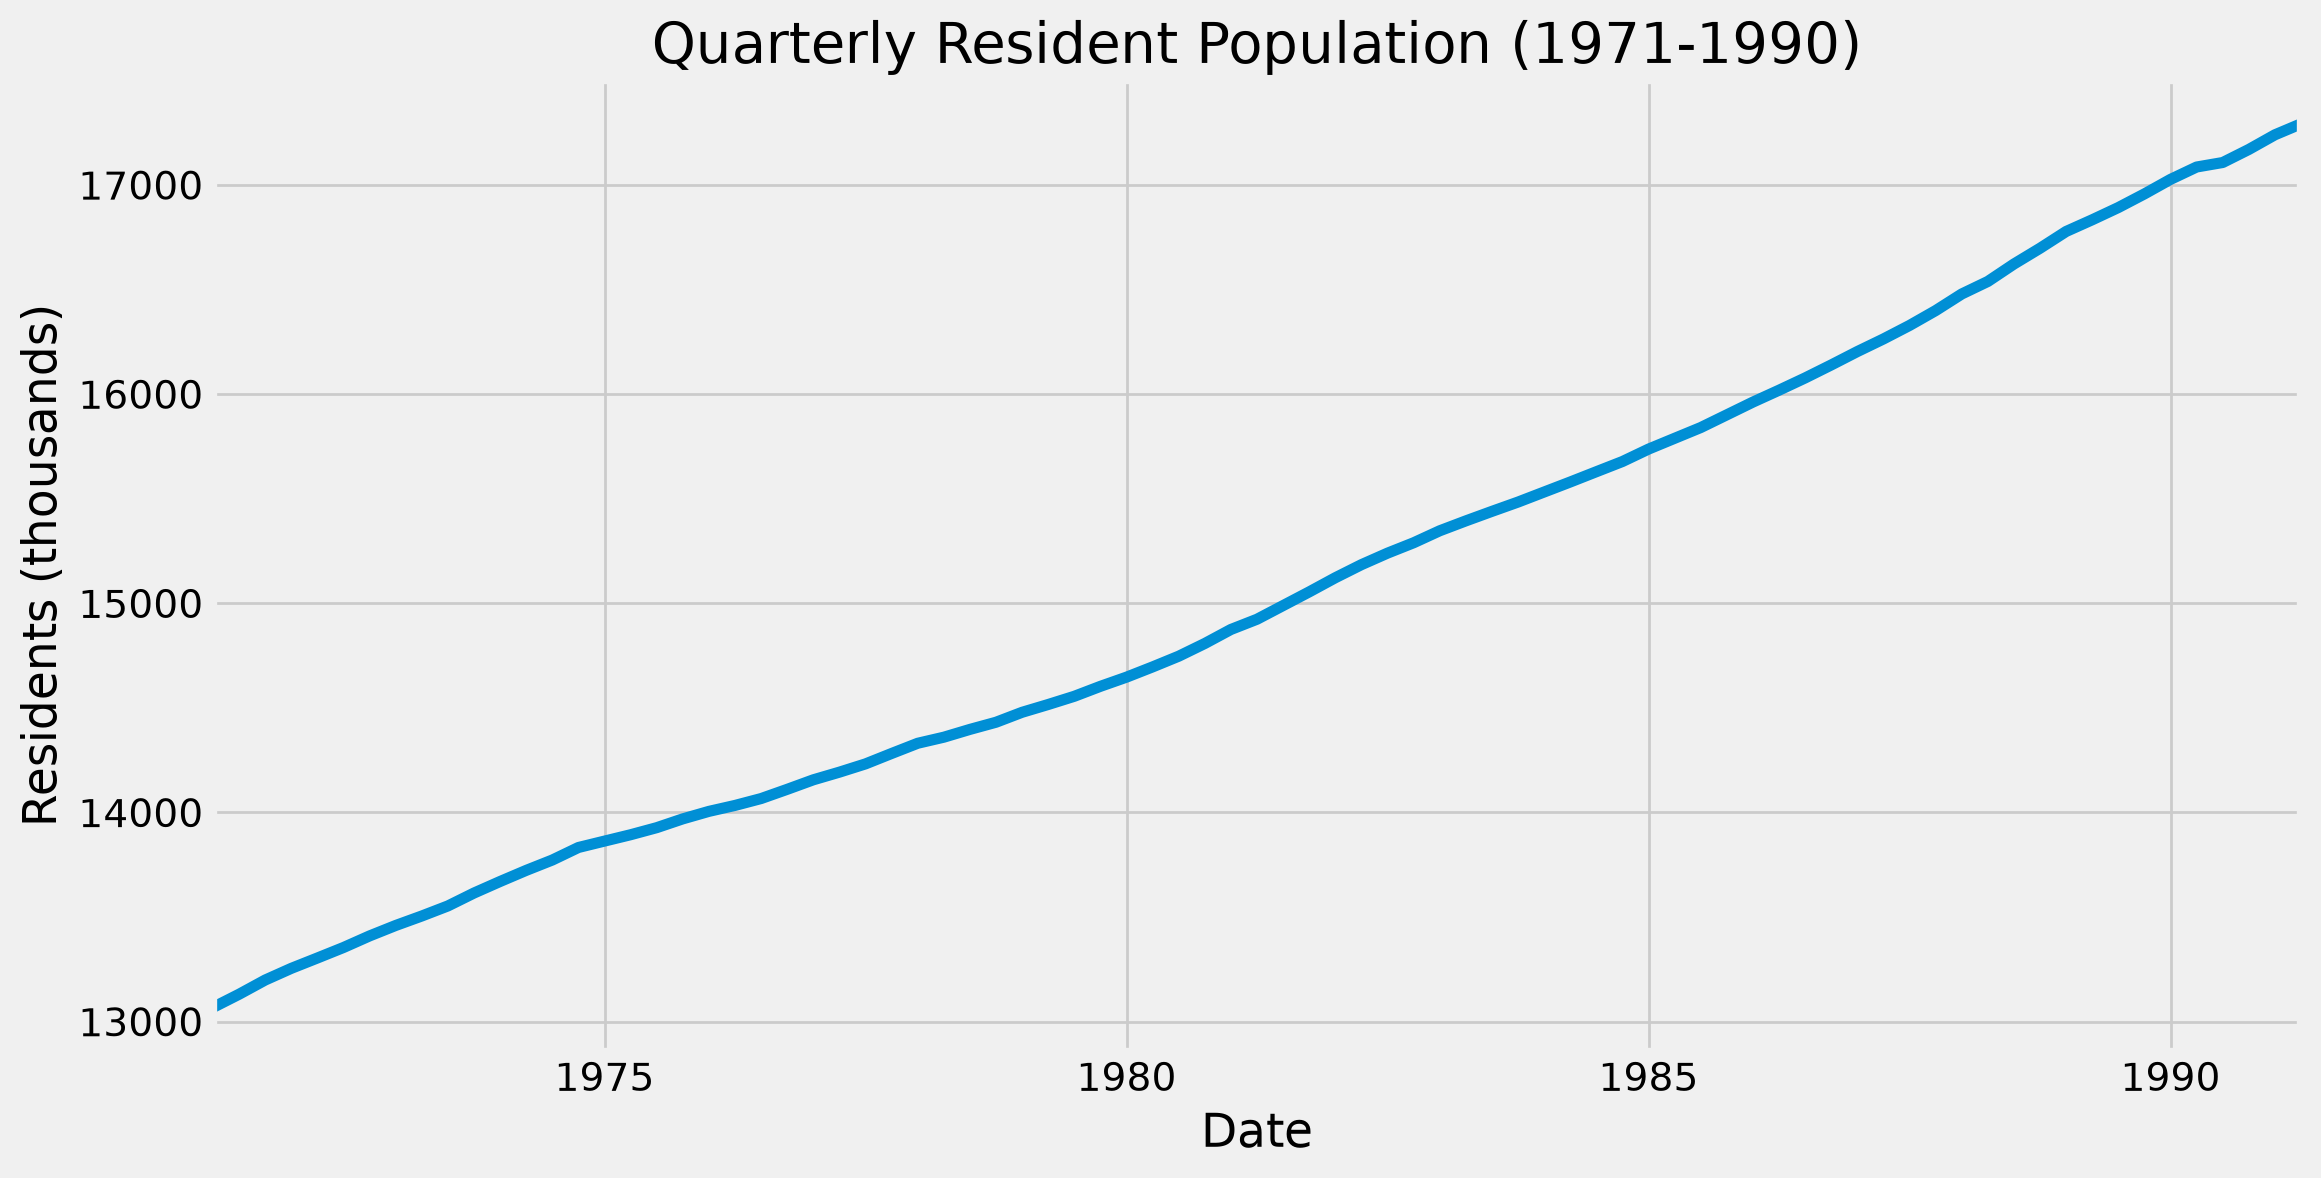

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))
df_eda['residents'].plot(ax=ax)
ax.set_title('Quarterly Resident Population (1971-1990)')
ax.set_ylabel('Residents (thousands)')
ax.set_xlabel('Date')
plt.show()

# Observations:
# - There is a clear, steady upward trend over the whole period - the series is not stationary in mean.
# - There is a repeating up-and-down wiggle within every year -> seasonality (period = 4 quarters).
# - The quarter-to-quarter spread looks fairly stable early on, but the swings appear to get a
#   little larger as the overall level rises later in the series (variance is not perfectly constant).

## Part 2 - Seasonal Decomposition

A time series can be split into three components: **trend**, **seasonal**, and **residual**.

### 4. Decompose `residents` using `seasonal_decompose` (`period=4` since this is quarterly data). Plot the trend, seasonal, and residual components.

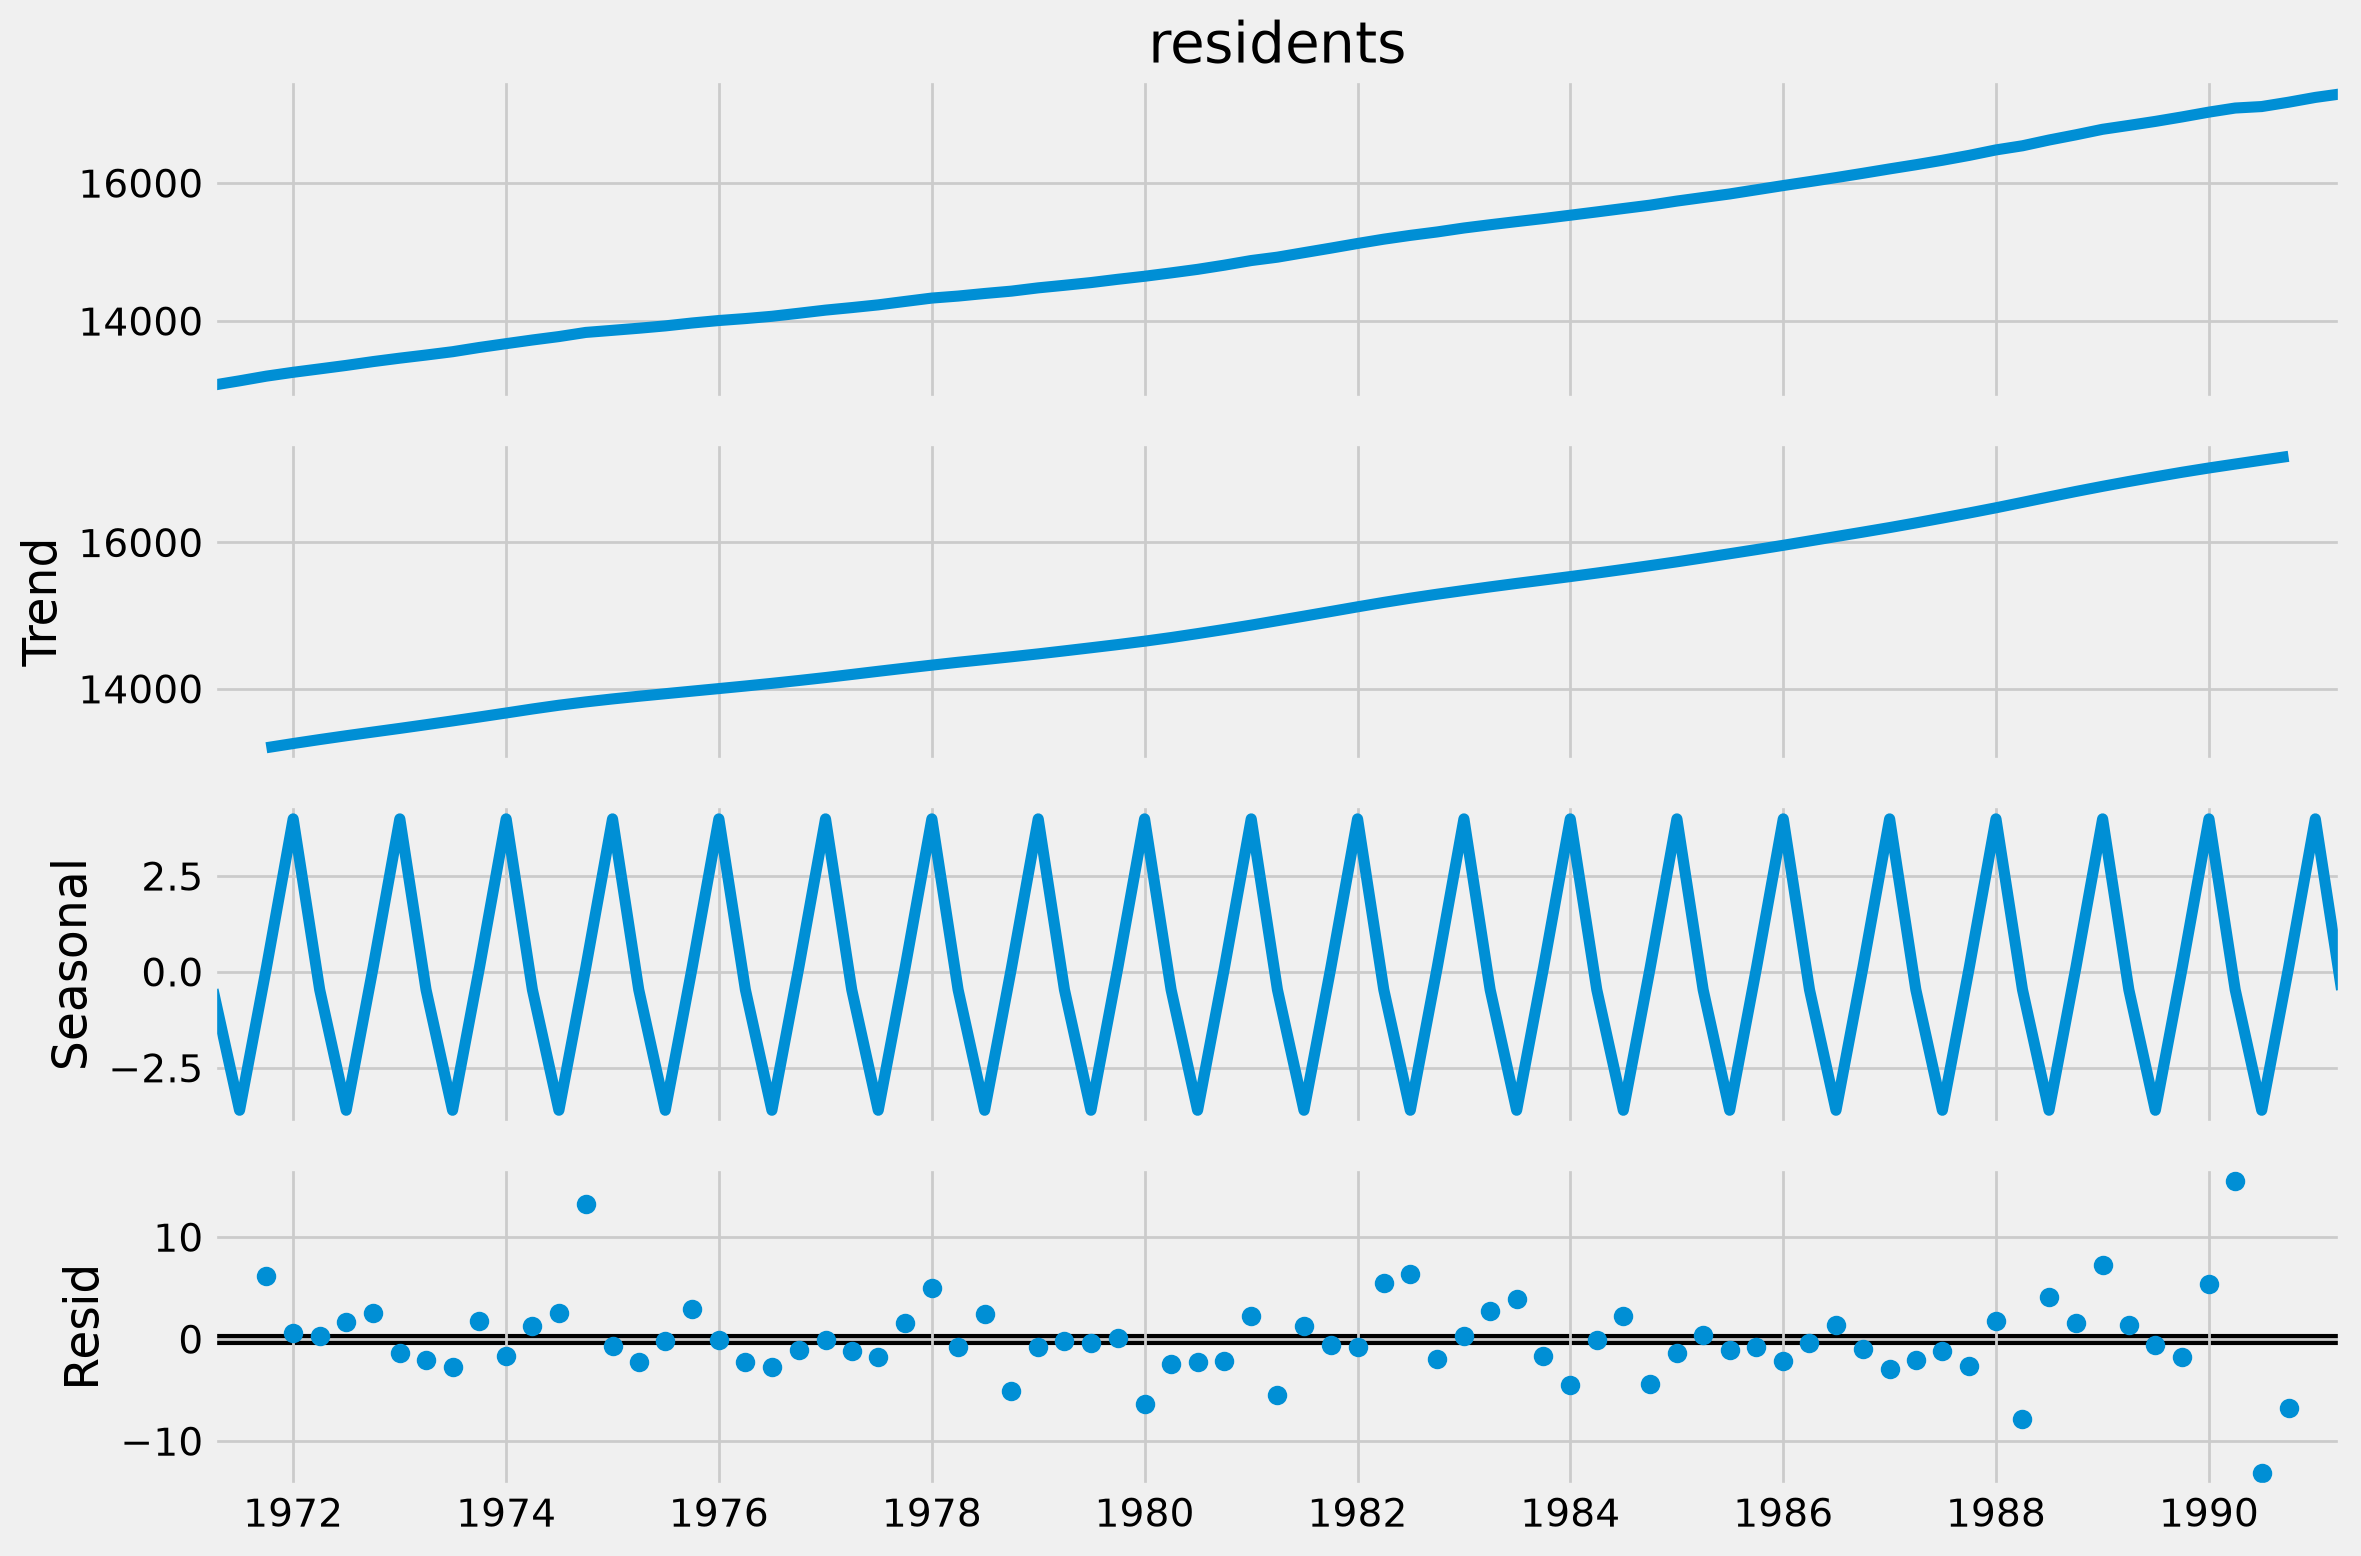

In [35]:
decomposition = seasonal_decompose(df_eda['residents'], period=4, model='additive')

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## Part 3 - Visualizing Trend with Rolling Mean and Resampling.

With quarterly data, a 4-quarter (1-year) rolling window is the suitable choice, as it averages away any seasonal fluctuations and leaves just the trend.

### 5. Compute and plot a 4-quarter rolling mean of `residents`, overlaid on the raw series.

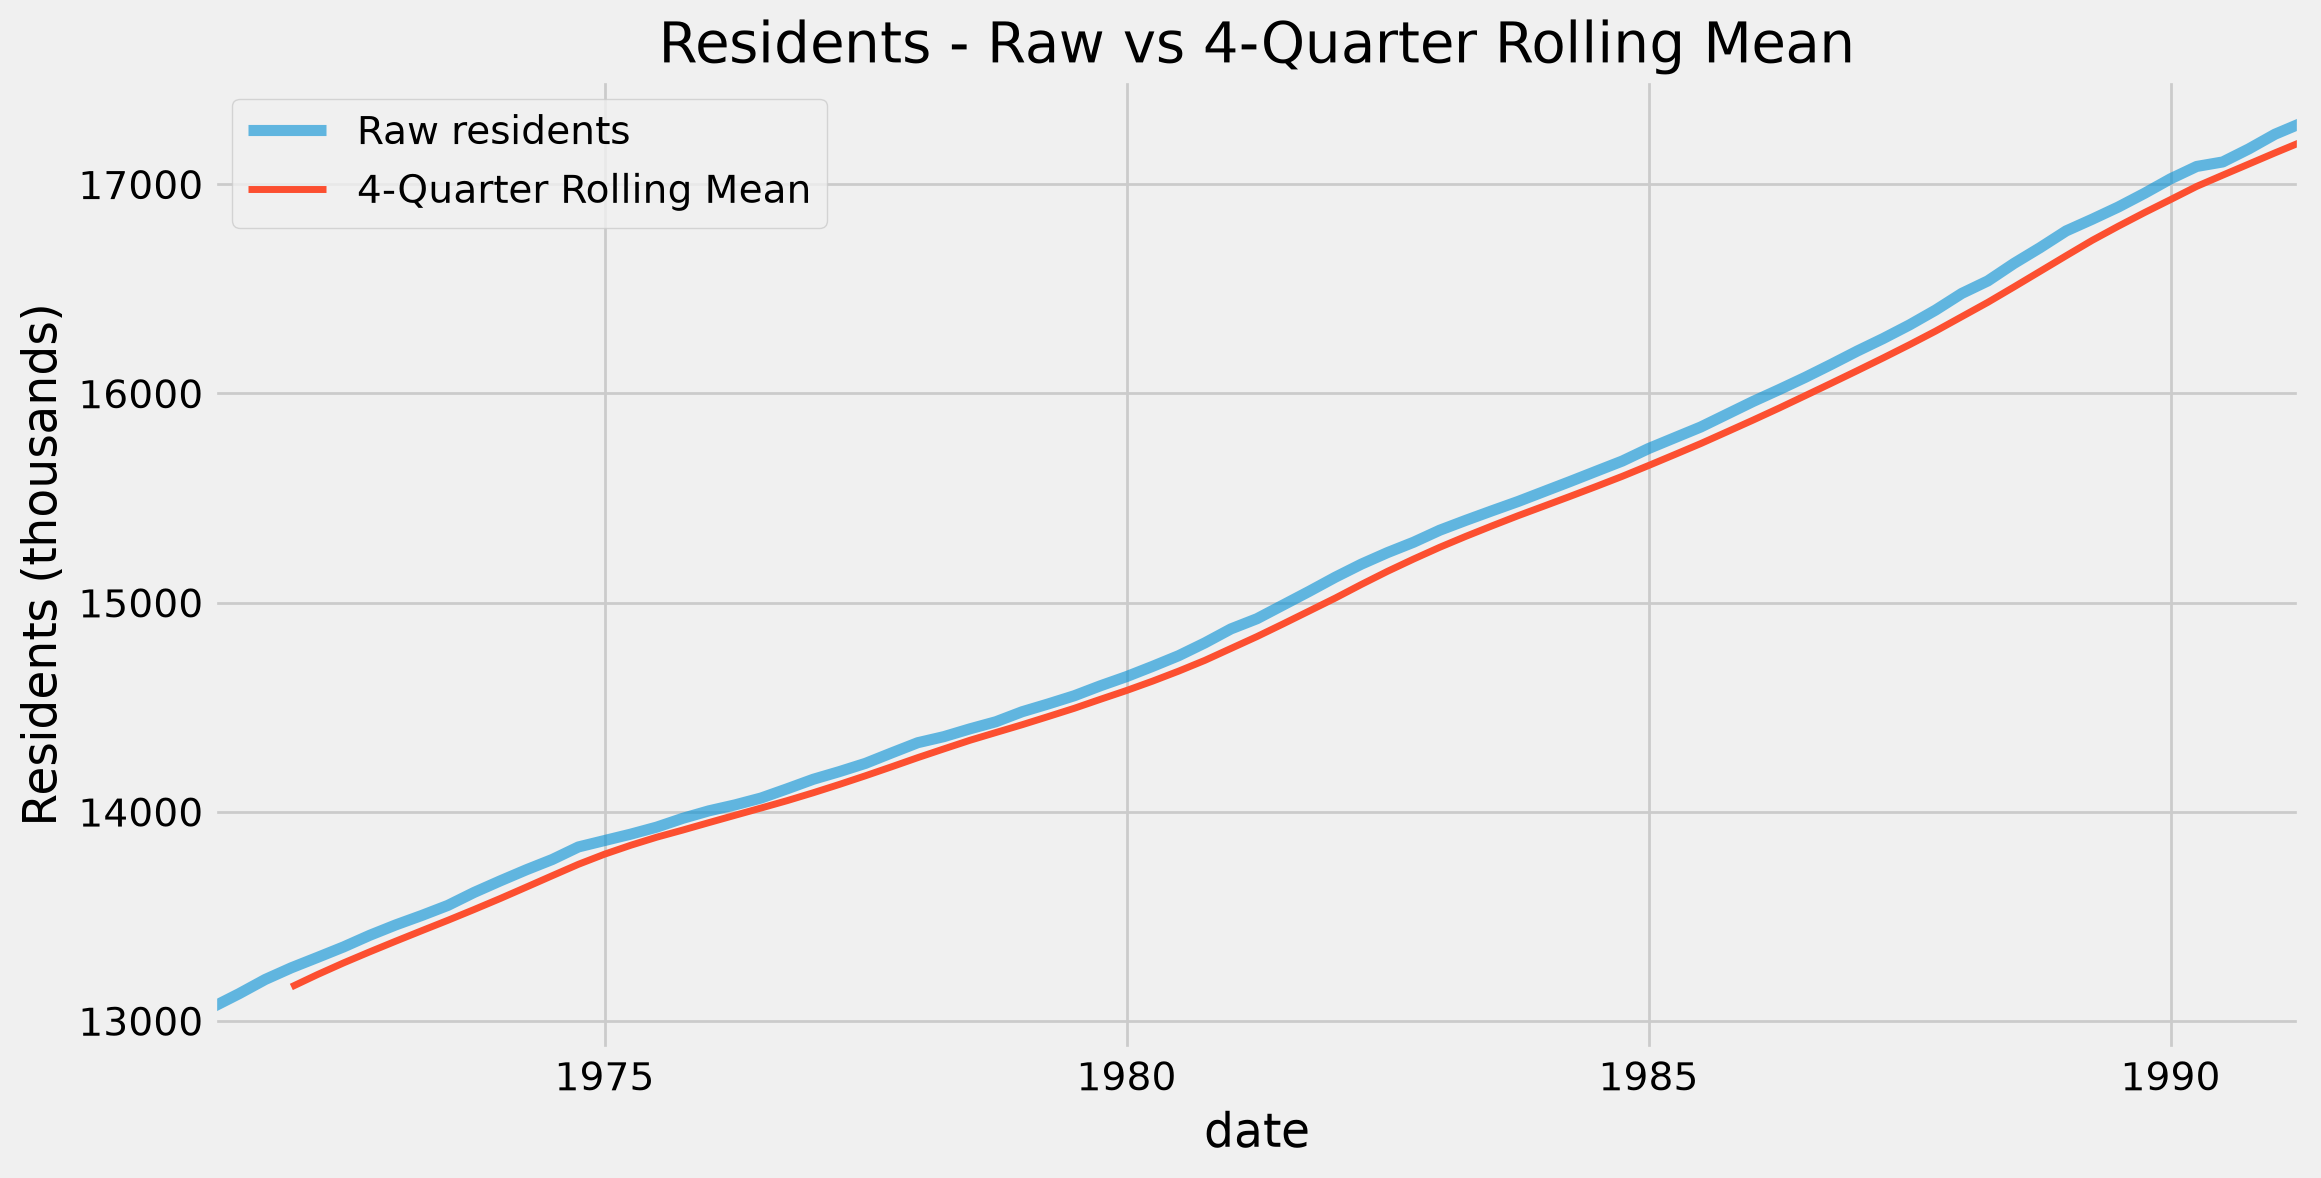

In [36]:
rolling_mean = df_eda['residents'].rolling(window=4).mean()

fig, ax = plt.subplots(figsize=(12, 6))
df_eda['residents'].plot(ax=ax, label='Raw residents', alpha=0.6)
rolling_mean.plot(ax=ax, label='4-Quarter Rolling Mean', linewidth=2.5)
ax.set_title('Residents - Raw vs 4-Quarter Rolling Mean')
ax.set_ylabel('Residents (thousands)')
ax.legend()
plt.show()

### 6. Plot a 4-quarter rolling standard deviation. Is the spread of fluctuations roughly stable over time, or does it change?

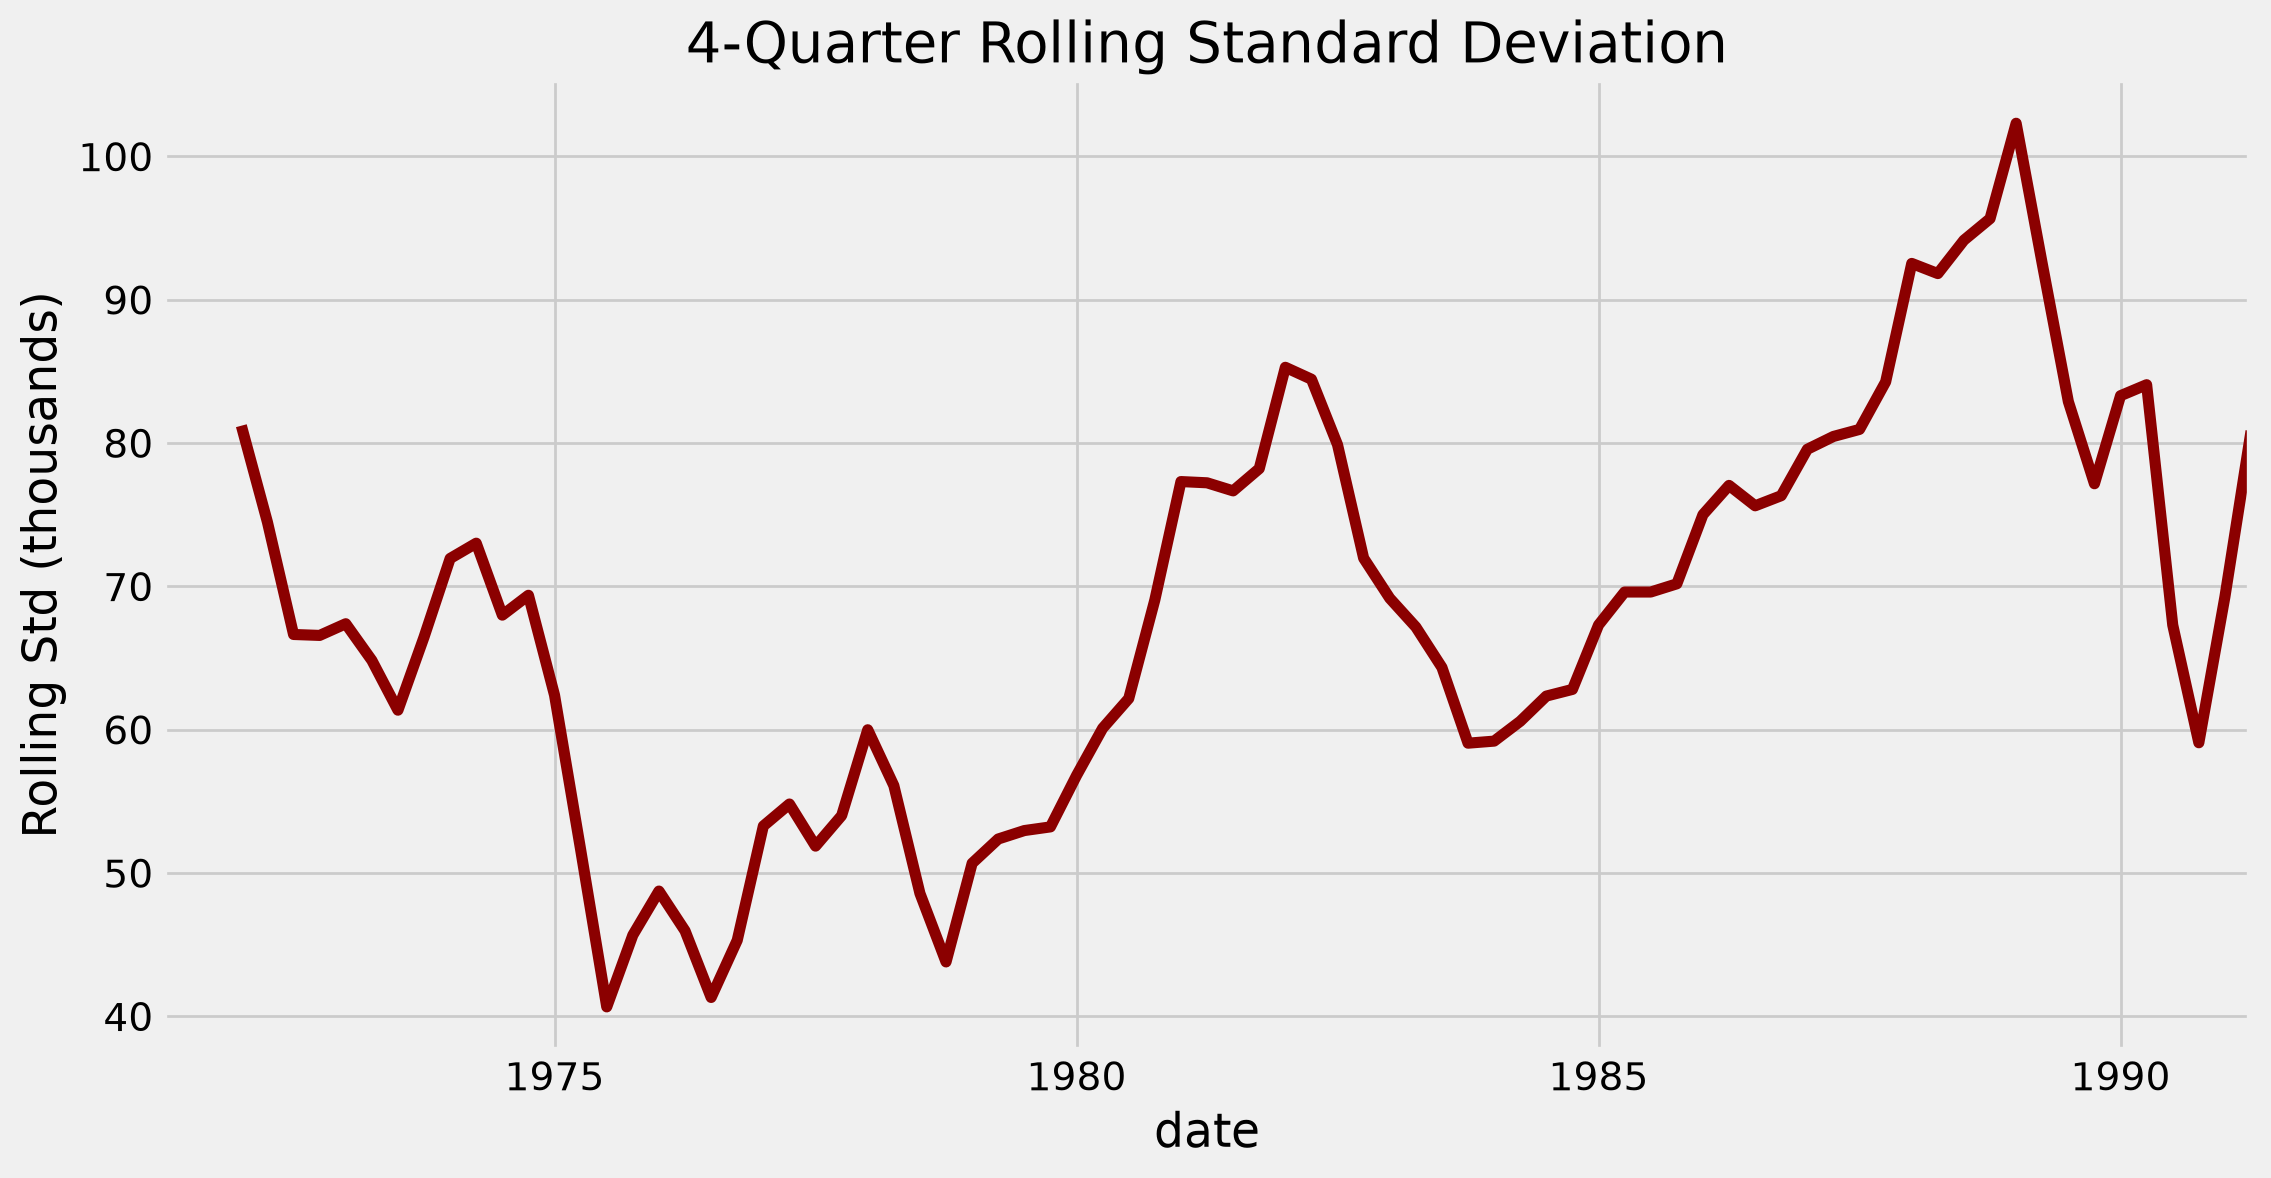

In [37]:
rolling_std = df_eda['residents'].rolling(window=4).std()

fig, ax = plt.subplots(figsize=(12, 6))
rolling_std.plot(ax=ax, color='darkred')
ax.set_title('4-Quarter Rolling Standard Deviation')
ax.set_ylabel('Rolling Std (thousands)')
plt.show()

# The rolling standard deviation is not flat - it drifts and grows over time rather than
# hovering around one constant value, which is another sign the raw series is non-stationary.

## Part 4 - Stationarity and the ADF Test

A stationary series has a constant mean, variance, and autocorrelation structure over time *(most classical forecasting models assume this)*. We test for it with the **Augmented Dickey-Fuller (ADF) test**:

- **Null hypothesis (H0):** the series has a unit root (i.e. it is *non-stationary*).
- If the p-value is small (typically ≤ 0.05), we reject H0 and conclude the series **is** *stationary*.

### 7. Write an `adf_test()` helper function that runs `adfuller()` and prints the test statistic, p-value, and a plain-English conclusion.

In [38]:
def adf_test(series):
    """
    Pass in a time series, and prints an ADF report.
    """
    result = adfuller(series.dropna())

    print('ADF Test Statistic : {:.4f}'.format(result[0]))
    print('p-value            : {:.4f}'.format(result[1]))
    print('# Lags Used        : {}'.format(result[2]))
    print('# Observations Used: {}'.format(result[3]))
    print('Critical Values:')
    for key, value in result[4].items():
        print('    {} : {:.4f}'.format(key, value))

    if result[1] <= 0.05:
        print('\n=> p-value <= 0.05: Reject H0. The series IS stationary.')
    else:
        print('\n=> p-value > 0.05: Fail to reject H0. The series is NOT stationary.')

### 8. Run `adf_test()` on the raw `residents` series. Then apply `.diff()` and run it again. Is one difference enough?

In [39]:
print('===== Raw series =====')
adf_test(df_eda['residents'])

print('\n===== First difference =====')
adf_test(df_eda['residents'].diff())

# The raw series has a high p-value (not stationary), which makes sense given the clear upward
# trend. After one .diff(), the p-value drops. Whether it drops below 0.05 determines if one
# difference is already enough, or if we need to go further (see next question).

===== Raw series =====
ADF Test Statistic : 1.8104
p-value            : 0.9984
# Lags Used        : 6
# Observations Used: 74
Critical Values:
    1% : -3.5220
    5% : -2.9015
    10% : -2.5881

=> p-value > 0.05: Fail to reject H0. The series is NOT stationary.

===== First difference =====
ADF Test Statistic : -2.5056
p-value            : 0.1141
# Lags Used        : 5
# Observations Used: 74
Critical Values:
    1% : -3.5220
    5% : -2.9015
    10% : -2.5881

=> p-value > 0.05: Fail to reject H0. The series is NOT stationary.


### 9. If the first difference wasn't enough, try a second difference (`.diff().diff()`). Is it stationary now? 
*This will be your `d` term in the modeling stage*.

In [40]:
print('===== Second difference =====')
adf_test(df_eda['residents'].diff().diff())

# If the first-differenced series was still not stationary (p-value > 0.05), the second
# difference should push the p-value below 0.05, confirming d=2 removes the remaining trend.
# If the first difference was already stationary, d=1 is sufficient and this is just a check.

===== Second difference =====
ADF Test Statistic : -3.1483
p-value            : 0.0232
# Lags Used        : 4
# Observations Used: 74
Critical Values:
    1% : -3.5220
    5% : -2.9015
    10% : -2.5881

=> p-value <= 0.05: Reject H0. The series IS stationary.


## Part 5 - Autocorrelation and Seasonality

ACF and PACF plots show how correlated a series is with its own past values at different lags. We look at these on the **differenced** series, with the trend removed, any repeating seasonal correlation stands out clearly instead of being buried under the trend's slow decay.

### 10. Plot the ACF and PACF of the series out to at least 20 lags.

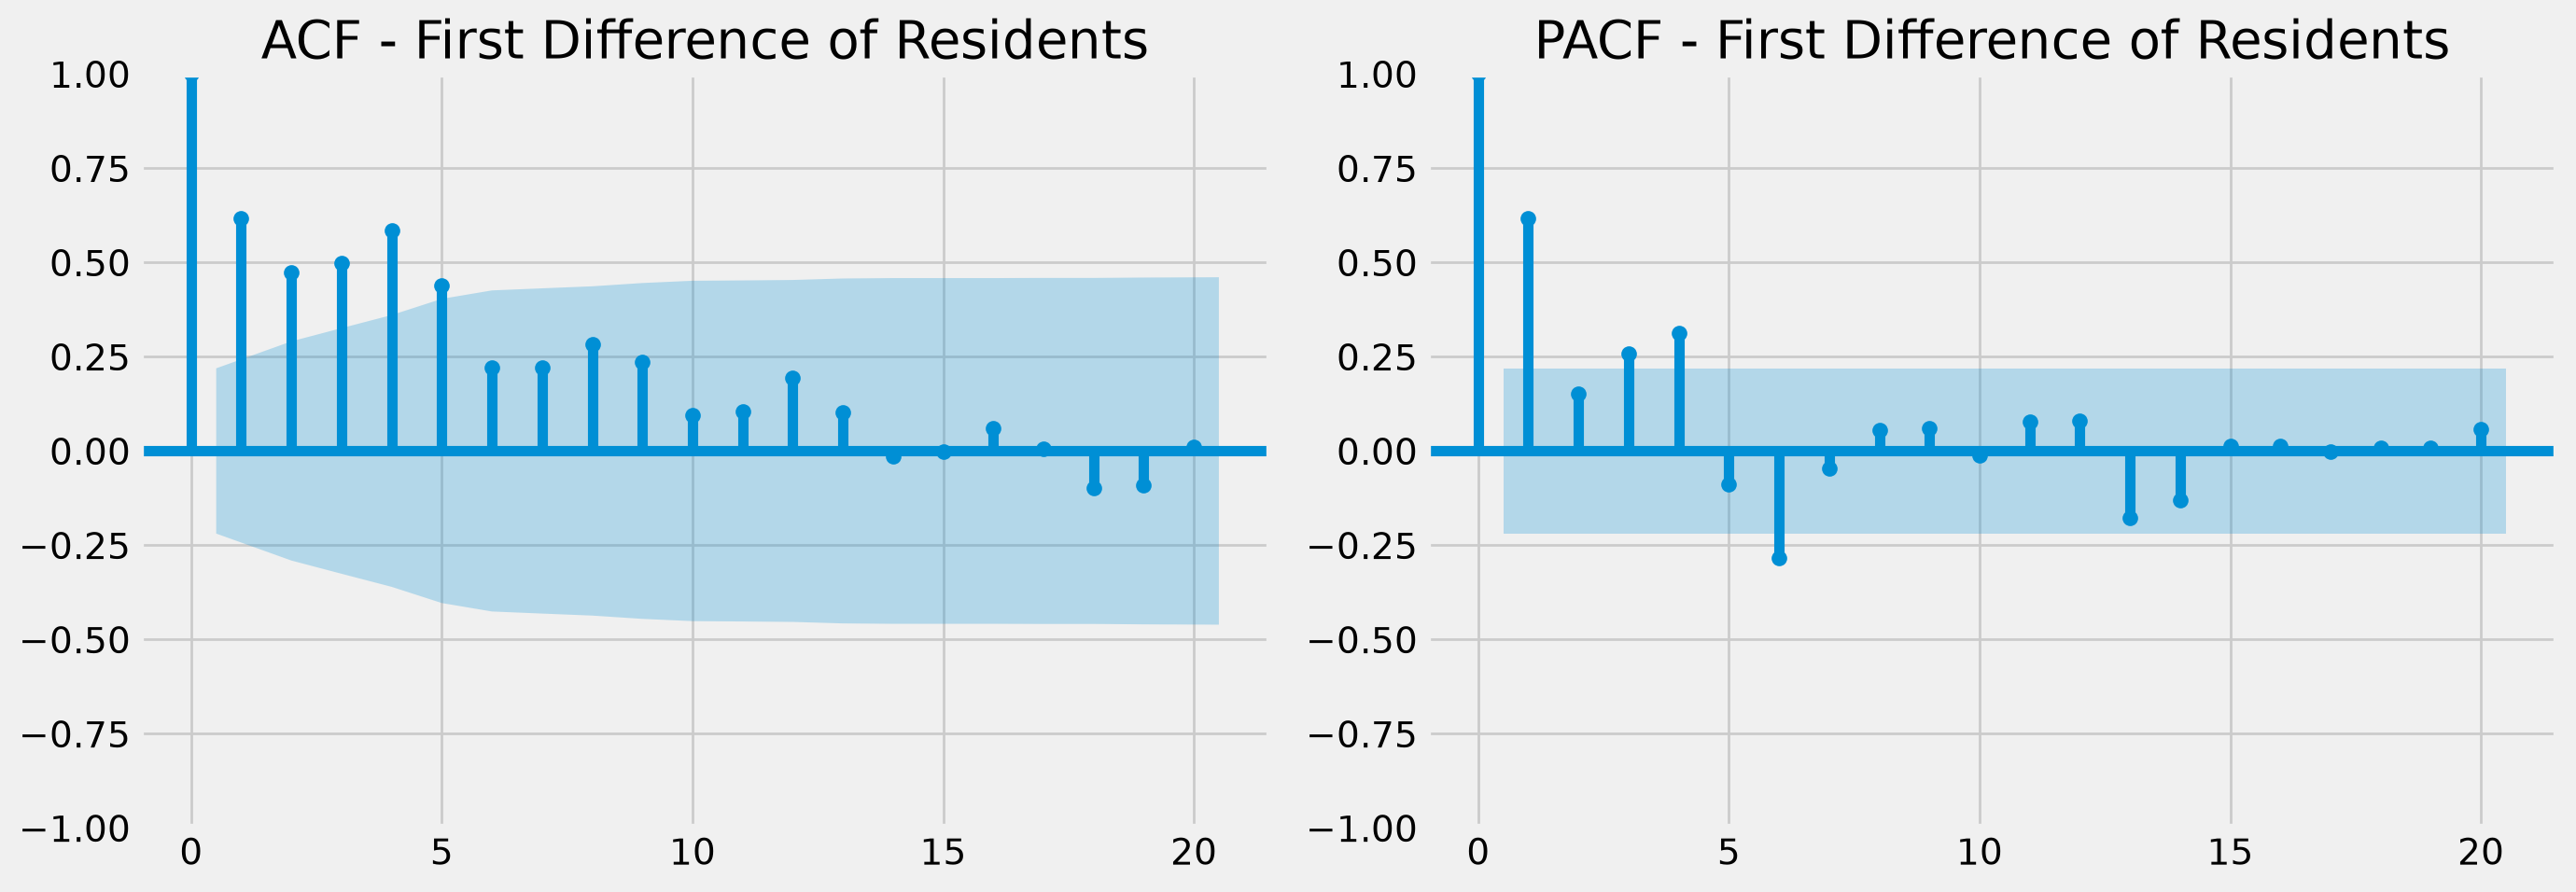

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df_eda['residents'].diff().dropna(), lags=20, ax=axes[0])
axes[0].set_title('ACF - First Difference of Residents')

plot_pacf(df_eda['residents'].diff().dropna(), lags=20, ax=axes[1])
axes[1].set_title('PACF - First Difference of Residents')

plt.tight_layout()
plt.show()

### 11. Look closely at the ACF plot. At which lag do you see the strongest spike? What does that tell you about the data?

The strongest spike in the ACF shows up at **lag 4** (and often echoes again around lag 8, 12, ...).
Since this is quarterly data, a spike every 4 lags means the series repeats itself every 4
quarters - i.e. every year. This is the signature of **yearly seasonality**, and it tells us we
should account for a seasonal component (e.g. a seasonal ARIMA / SARIMA with `s=4`) rather than
treating the series as purely non-seasonal when we get to modeling.